# Fetch Ligands

This notebook fetch the antibiotics and (ligands with highest
$IC_{50}$ for the given targets) from ChEMBL database using 
`chembl_webresource_client 0.10.9=pyhd8ed1ab_0` python library.

In [ ]:
from typing import Optional

import pandas as pd
import matplotlib.pyplot as plt
from pubchempy import Compound, get_compounds, download
from chembl_webresource_client.new_client import new_client
from PIL import Image
from rdkit import Chem
from rdkit.Chem import (
    AllChem,
    Mol,
    rdCoordGen,
    rdDepictor,
    PandasTools,
    Draw
)
from rdkit.Chem.Draw import IPythonConsole
from propka import protonate


In [2]:
%matplotlib inline
%config InlineBackend.figure_format="retina"
IPythonConsole.drawOptions.addAtomIndices = False


# Retrieval

In [3]:
antibiotics = [
        "amoxicillin", # penicillins
        "piperacillin",
        "ticarcillin",
        "cefepime", # cephalosporins
        "cefazolin",
        "ceftolozane",
        "ceftriaxone",
        "ceftazidime",
        "aztreonam", # monobactam
        "imipenem", # carbapenems
        "meropenem",
        "doripenem",
        "vancomycin", # glycopeptide
        "minocycline", # tetracyclines
        "tigecycline",
        "doxycycline",
        "tetracycline",
        "Chlortetracycline",
        "azithromycin", # macrolides
        "erythromycin",
        "clarithromycin",
        "chloramphenicol", # chlorampenicol
        "linezolid", # oxazolidinones
        "amikacin", # aminoglycosides
        "tobramycin",
        "streptomycin",
        "kanamycin",
        "trimethoprim", # trimethoprim
        "sulfamethoxazole", # sulfamethoxazole
        "ciprofloxacin", # quinolones
        "levofloxacin",
        "Moxifloxacin"
    ]


In [102]:
ab_cid: dict[str, dict] = {}

for ab in antibiotics:
    res = get_compounds(ab, "name", record_type="3d")
    if len(res) == 0:
        res = get_compounds(ab, "name")
    cid = res[0].cid
    ab_cid[ab] = Compound.from_cid(cid).to_dict(
            [
                "cid",
                "smiles",
                "inchi",
                "coordinate_type",
                "xlogp",
                "tpsa",
                "h_bond_donor_count",
                "h_bond_acceptor_count",
                "rotatable_bond_count",
                "cactvs_fingerprint"
            ]
        )
    download("sdf", f"../data/sdf/{cid}.sdf", cid, overwrite=True)


In [103]:
compound_query = pd.DataFrame(ab_cid)
compound_query


,amoxicillin,piperacillin,ticarcillin,cefepime,cefazolin,ceftolozane,ceftriaxone,ceftazidime,aztreonam,imipenem,...,linezolid,amikacin,tobramycin,streptomycin,kanamycin,trimethoprim,sulfamethoxazole,ciprofloxacin,levofloxacin,Moxifloxacin
cid,33613,43672,36921,5479537,33255,53234134,5479530,5481173,5742832,104838,...,441401,37768,36294,19649,6032,5578,5329,2764,149096,152946
smiles,CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H]...,CCN1CCN(C(=O)C1=O)C(=O)N[C@H](C2=CC=CC=C2)C(=O...,CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H]...,C[N+]1(CCCC1)CC2=C(N3[C@@H]([C@@H](C3=O)NC(=O)...,CC1=NN=C(S1)SCC2=C(N3[C@@H]([C@@H](C3=O)NC(=O)...,CC(C)(C(=O)O)O/N=C(/C1=NSC(=N1)N)\C(=O)N[C@H]2...,CN1C(=NC(=O)C(=O)N1)SCC2=C(N3[C@@H]([C@@H](C3=...,CC(C)(C(=O)O)O/N=C(/C1=CSC(=N1)N)\C(=O)N[C@H]2...,C[C@H]1[C@@H](C(=O)N1S(=O)(=O)O)NC(=O)/C(=N\OC...,C[C@H]([C@@H]1[C@H]2CC(=C(N2C1=O)C(=O)O)SCCN=CN)O,...,CC(=O)NC[C@H]1CN(C(=O)O1)C2=CC(=C(C=C2)N3CCOCC3)F,C1[C@@H]([C@H]([C@@H]([C@H]([C@@H]1NC(=O)[C@H]...,C1[C@@H]([C@H]([C@@H]([C@H]([C@@H]1N)O[C@@H]2[...,C[C@H]1[C@@]([C@H]([C@@H](O1)O[C@@H]2[C@H]([C@...,C1[C@H]([C@@H]([C@H]([C@@H]([C@H]1N)O[C@@H]2[C...,COC1=CC(=CC(=C1OC)OC)CC2=CN=C(N=C2N)N,CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N,C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)C(=O)O,C[C@H]1COC2=C3N1C=C(C(=O)C3=CC(=C2N4CCN(CC4)C)...,COC1=C2C(=CC(=C1N3C[C@@H]4CCCN[C@@H]4C3)F)C(=O...
inchi,InChI=1S/C16H19N3O5S/c1-16(2)11(15(23)24)19-13...,InChI=1S/C23H27N5O7S/c1-4-26-10-11-27(19(32)18...,InChI=1S/C15H16N2O6S2/c1-15(2)9(14(22)23)17-11...,InChI=1S/C19H24N6O5S2/c1-25(5-3-4-6-25)7-10-8-...,InChI=1S/C14H14N8O4S3/c1-6-17-18-14(29-6)28-4-...,"InChI=1S/C23H30N12O8S2/c1-23(2,20(40)41)43-31-...",InChI=1S/C18H18N8O7S3/c1-25-18(22-12(28)13(29)...,"InChI=1S/C22H22N6O7S2/c1-22(2,20(33)34)35-26-1...","InChI=1S/C13H17N5O8S2/c1-5-7(10(20)18(5)28(23,...",InChI=1S/C12H17N3O4S/c1-6(16)9-7-4-8(20-3-2-14...,...,InChI=1S/C16H20FN3O4/c1-11(21)18-9-13-10-20(16...,InChI=1S/C22H43N5O13/c23-2-1-8(29)20(36)27-7-3...,InChI=1S/C18H37N5O9/c19-3-9-8(25)2-7(22)17(29-...,"InChI=1S/C21H39N7O12/c1-5-21(36,4-30)16(40-17-...",InChI=1S/C18H36N4O11/c19-2-6-10(25)12(27)13(28...,InChI=1S/C14H18N4O3/c1-19-10-5-8(6-11(20-2)12(...,InChI=1S/C10H11N3O3S/c1-7-6-10(12-16-7)13-17(1...,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,InChI=1S/C18H20FN3O4/c1-10-9-26-17-14-11(16(23...,InChI=1S/C21H24FN3O4/c1-29-20-17-13(19(26)14(2...
coordinate_type,2d,2d,2d,2d,2d,2d,2d,2d,2d,2d,...,2d,2d,2d,2d,2d,2d,2d,2d,2d,2d
xlogp,-2,0.5,0.8,-0.1,-0.4,-3.2,-1.3,0.4,0.3,-0.7,...,0.7,-7.9,-6.2,-8,-6.9,0.9,0.9,-1.1,-0.4,0.6
tpsa,158,182,178,204,235,356,288,245,238,142,...,71.1,332,268,336,283,106,107,72.9,73.3,82.1
h_bond_donor_count,4,3,3,2,2,7,4,3,4,3,...,1,13,10,12,11,2,2,2,1,2
h_bond_acceptor_count,7,8,8,10,12,16,13,12,12,6,...,6,17,14,15,15,7,6,7,8,8
rotatable_bond_count,4,6,5,6,7,11,8,8,7,6,...,4,10,6,9,6,5,3,3,2,4
cactvs_fingerprint,1110000001111011001110000000000001000000000000...,1110000001111011101110000000000001000000000000...,1110000001110011001110000000000001100000000000...,1110000001111011101110000000000001100000000000...,1100000001110011111110000000000001100000000000...,1110000001111011111111000000000001100000000000...,1110000001111011111110000000000001100000000000...,1110000001111011101110000000000001100000000000...,1110000001110011101111000000000001100000000000...,1110000001110011001110000000000001000000000000...,...,1110000001111011001110010000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1110000001110011101100000000000000000000000000...,1100000001110011001100000000000001000000000000...,1110000001111011001100010000000000000000000000...,1110000001111011001110010000000000000000000000...,1110000001111011001110010000000000000000000000...


In [104]:
compound_query.to_csv("../data/output/antibiotics_pubchem_query.csv")


# 

In [5]:
molecule_client = new_client.molecule


In [6]:
chembl_molecules = []
chembl_mol_df = {}

for ab_ in antibiotics:
    chembl_mol = molecule_client.filter(
        pref_name__iexact=ab_.upper()
    ).only(
        [
            "molecule_chembl_id",
            "pref_name",
            "molecule_structures"
        ]
    )
    result = chembl_mol[0]
    parsed_query = {
            "name": result["pref_name"],
            "chembl_id": result["molecule_chembl_id"],
            "mol_struct": result["molecule_structures"]
        }
    chembl_molecules.append(parsed_query)
    chembl_mol_df[result["pref_name"]] = parsed_query


In [7]:
molecules_df = pd.DataFrame(chembl_molecules)
molecules_df


,name,chembl_id,mol_struct
0,AMOXICILLIN,CHEMBL1082,{'canonical_smiles': 'CC1(C)S[C@@H]2[C@H](NC(=...
1,PIPERACILLIN,CHEMBL702,{'canonical_smiles': 'CCN1CCN(C(=O)N[C@@H](C(=...
2,TICARCILLIN,CHEMBL1449,{'canonical_smiles': 'CC1(C)S[C@@H]2[C@H](NC(=...
3,CEFEPIME,CHEMBL186,{'canonical_smiles': 'CO/N=C(\C(=O)N[C@@H]1C(=...
4,CEFAZOLIN,CHEMBL1435,{'canonical_smiles': 'Cc1nnc(SCC2=C(C(=O)O)N3C...
5,CEFTOLOZANE,CHEMBL2103872,{'canonical_smiles': 'Cn1c(N)c(NC(=O)NCCN)c[n+...
6,CEFTRIAXONE,CHEMBL161,{'canonical_smiles': 'CO/N=C(\C(=O)N[C@@H]1C(=...
7,CEFTAZIDIME,CHEMBL44354,{'canonical_smiles': 'CC(C)(O/N=C(\C(=O)N[C@@H...
8,AZTREONAM,CHEMBL158,{'canonical_smiles': 'C[C@H]1[C@H](NC(=O)/C(=N...
9,IMIPENEM,CHEMBL43708,{'canonical_smiles': 'C[C@@H](O)[C@H]1C(=O)N2C...


In [8]:
molecules_df.to_csv("../data/output/antibiotics_chembl.csv")


In [9]:
struct_ = chembl_mol_df["AMOXICILLIN"]["mol_struct"]["canonical_smiles"]


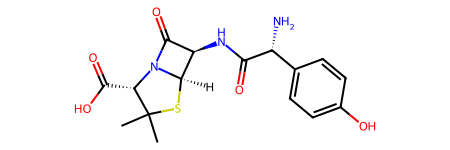

In [10]:
mol = Chem.MolFromSmiles(struct_)
mol


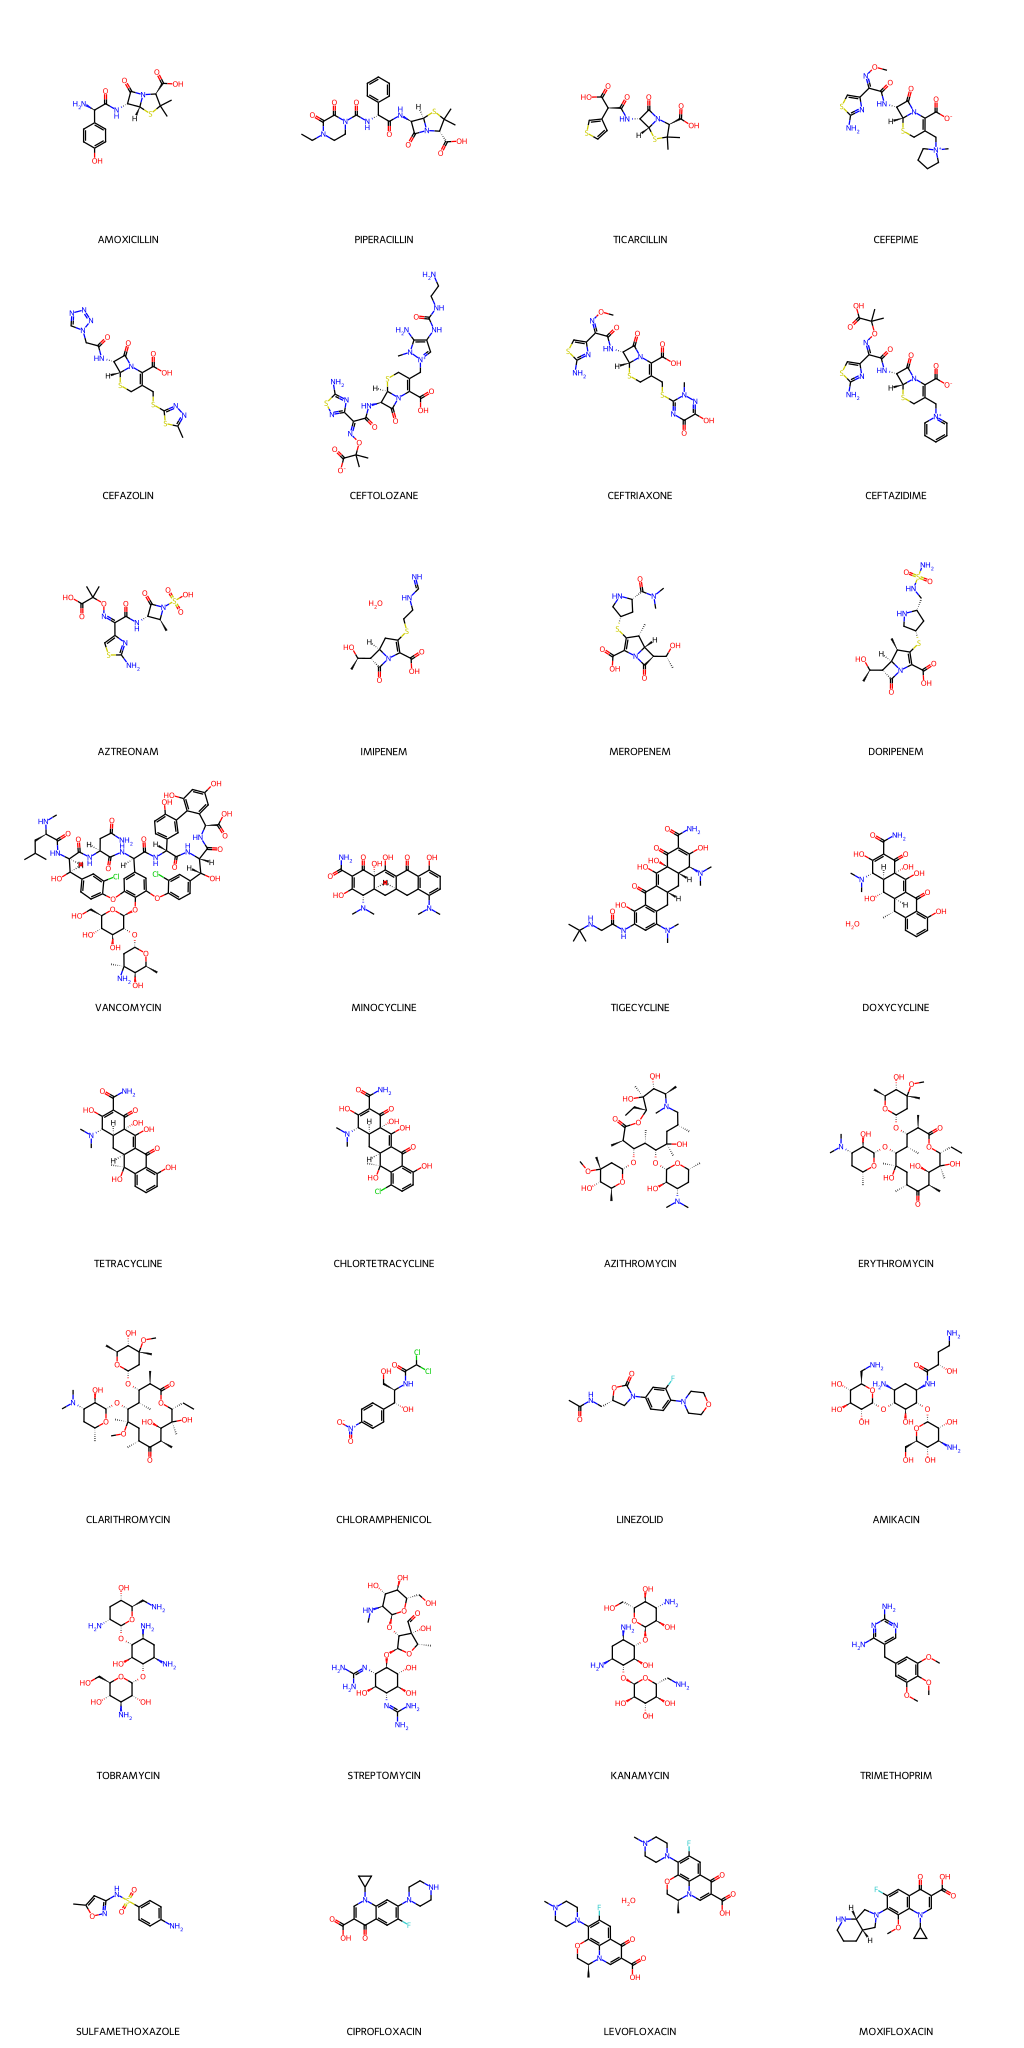

In [11]:
mols = []
names = []
rdDepictor.SetPreferCoordGen(True)
for ab_ in chembl_molecules:
    struct_ = ab_["mol_struct"]["canonical_smiles"]
    name = ab_["name"]
    chembl_id = ab_["chembl_id"]
    names.append(name)
    mol = Chem.MolFromSmiles(struct_)
    # for atom in mol.GetAtoms():
    #     atom.SetProp("atomLabel", atom.GetSymbol())
    mols.append(mol)

mols_per_row = min(len(chembl_molecules), 4)
img = Draw.MolsToGridImage(
        mols, molsPerRow=mols_per_row,
        subImgSize=(400, 400), useSVG=True,
        legends=names
    )

img


In [25]:
def get_structure(
        mol: Mol,
        num_conformations: int,
        index: int = 0
    ) -> Optional[Mol]:
    mol = Chem.AddHs(mol)
    new_mol = Chem.Mol(mol)

    conformer_energies = []
    try:
        AllChem.EmbedMultipleConfs(
            mol,
            numConfs=num_conformations,
            useExpTorsionAnglePrefs=True,
            useBasicKnowledge=True
        )
        conformer_energies = AllChem.MMFFOptimizeMoleculeConfs(
                mol, maxIters=2000, nonBondedThresh=100.0
            )
    except ValueError:
        return None

    if index == 0:
        try:
            i = conformer_energies.index(min(conformer_energies))
        except ValueError:
            return None
    elif index > 0:
        i = index - 1
    else:
        raise ValueError("index cannot be less that zero.")

    new_mol.AddConformer(mol.GetConformer(i))
    return new_mol


def molecule_to_sdf(
        mol: Mol,
        output_filename: str,
        name: Optional[str] = None
    ) -> None:
    mol.SetProp("_Name", name)
    Chem.SDWriter("{}".format(output_filename)).write(mol)


In [21]:
struct_


'COc1c(N2C[C@@H]3CCCN[C@@H]3C2)c(F)cc2c(=O)c(C(=O)O)cn(C3CC3)c12'

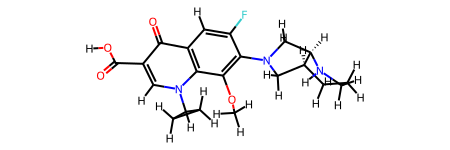

In [40]:
get_structure(Chem.MolFromSmiles(struct_), 1)
